# How can we help our user select the best price?

我们希望于 在线分类的汽车网站中，帮我朋友找到最佳价格。
用户想要卖车，但不知道该如何定价？
开发一个模型，帮他实现这个目标。

数据集网址：https://www.kaggle.com/datasets/CooperUnion/cardataset

# Project plan   
Prepare data and do EDA (Exploratory Data Analysis)  准备数据并进行探索性数据分析（EDA）

Use linear regression for predicting price           使用线性回归预测价格

Understand the internals of linear regression        理解线性回归的内部原理

Evaluating the model with RMSE                       使用RMSE评估模型

Feature engineering                                  特征工程

Regularization                                       正则化解决模型问题

# 1. 数据下载，并手动移动到当前目录中  ，
***注意需要按照上述kaggle官网中，获取token api的方式，安装kagglehub库及配置API，才能正确下载***

In [9]:
import kagglehub

# 下载数据集 Download latest version
path = kagglehub.dataset_download("CooperUnion/cardataset")

print("Path to dataset files:", path)
# 输出类似：/root/.cache/kagglehub/datasets/CooperUnion/cardataset/versions/1

# 查看下载了哪些文件
import os
files = os.listdir(path)
print("Files:", files)  # ['car.csv', 'data_description.txt', ...]

Path to dataset files: /root/.cache/kagglehub/datasets/CooperUnion/cardataset/versions/1
Files: []


# 2. Machine Learning for Regression

In [2]:
import pandas  as pd
import numpy as np

## 2.2 Data preparation

In [87]:
df = pd.read_csv('data.csv')

In [88]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [89]:
df['make'].str.lower().str.replace(' ','_')

0            bmw
1            bmw
2            bmw
3            bmw
4            bmw
          ...   
11909      acura
11910      acura
11911      acura
11912      acura
11913    lincoln
Name: make, Length: 11914, dtype: str

In [90]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [91]:
strings = list(df.dtypes[df.dtypes == 'str'].index)  # 找到属性是‘str’的所有字段
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [92]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ','_')

In [93]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [94]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

## 2.3 探索性数据分析   exploratory  data  analysis

## 2.3.1 长尾数据 转换为 对数方式的正态分布数据

In [95]:
for col in list(df.columns):
    print(col)
    print(df[col].head(5))
    print(df[col].unique())
    print(df[col].unique()[:5])  #:5 取前5个元素,是 [0:5] 的简写
    # print(df[col].nunique())  # 统计unique结果的数量
    print('-------------------------------------------------------------------')

make
0    bmw
1    bmw
2    bmw
3    bmw
4    bmw
Name: make, dtype: str
<ArrowStringArray>
[          'bmw',          'audi',          'fiat', 'mercedes-benz',
      'chrysler',        'nissan',         'volvo',         'mazda',
    'mitsubishi',       'ferrari',    'alfa_romeo',        'toyota',
       'mclaren',       'maybach',       'pontiac',       'porsche',
          'saab',           'gmc',       'hyundai',      'plymouth',
         'honda',    'oldsmobile',        'suzuki',          'ford',
      'cadillac',           'kia',       'bentley',     'chevrolet',
         'dodge',   'lamborghini',       'lincoln',        'subaru',
    'volkswagen',        'spyker',         'buick',         'acura',
   'rolls-royce',      'maserati',         'lexus',  'aston_martin',
    'land_rover',         'lotus',      'infiniti',         'scion',
       'genesis',        'hummer',         'tesla',       'bugatti']
Length: 48, dtype: str
<ArrowStringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib  inline   
#让 matplotlib 画的图直接嵌入在notebook里显示出来，而不是弹出一个新窗口。

<function matplotlib.pyplot.show(close=None, block=None)>

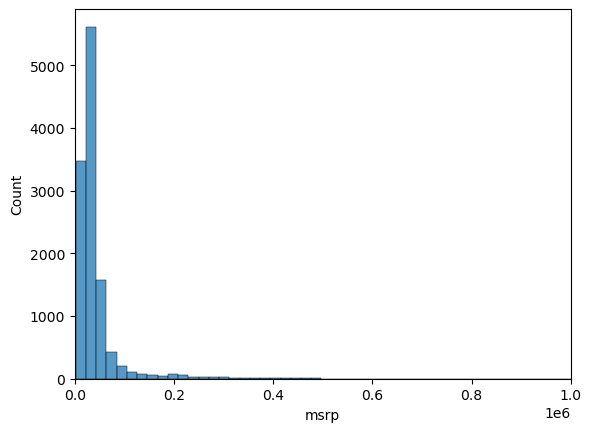

In [99]:
sns.histplot(df.msrp,bins=100 ) # 把数据的取值范围（最小值到最大值）等分成 100 个等宽的小区间（bins），
#然后统计每个区间里有多少辆车。
plt.xlim(0,1000000)
plt.show

### 价格便宜的车量占据了绝大多数，价格贵得车辆占据了极少数，且呈现long tail模式，长尾模式

<Axes: xlabel='msrp', ylabel='Count'>

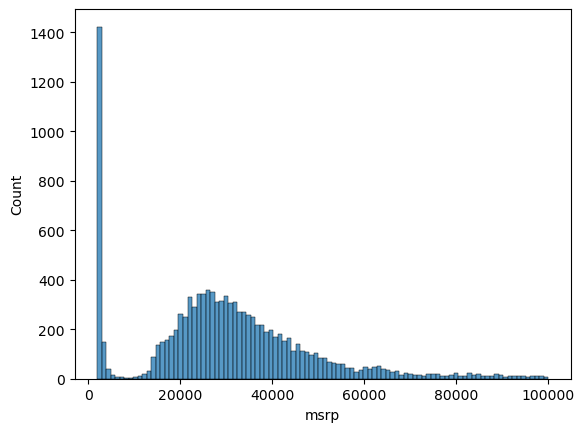

In [100]:
sns.histplot(df.msrp[df['msrp'] < 100000],bins=100 ) # 在报价小于10万的范围内，显示价格分布

### 原始价格：
6万、8万、10万→ 差距是翻倍
直方图：右边被拉得很长，左边挤成一团
### 过高价格的车辆的数据，就是长尾部分多所代表的数据，会对模型训练产生不利影响，现在需要***去掉这个长尾***
### ***通常的做法是***：对数分布，也就是对价格取对数，这样就能得到更紧凑的值。
log₂(8) = 3  读作："以 2 为底，8 的对数是 3"
取对数后：
log(3万)、log(6万)、log(12万)、log(24万)
差距变成：+0.3、+0.3、+0.3 → 均匀了
效果：直方图从"右边长尾巴"变成"钟形"，更容易看清主流价格区间。

In [101]:
# np.log([0+1,1+1,10+1,1000+1,100000+1])   #把汽车价格取对数，但避免价格等于0时程序崩溃
np.log1p([0,1,10,1000,100000,0.00000001])   # 同上，另一种写法

array([0.00000000e+00, 6.93147181e-01, 2.39789527e+00, 6.90875478e+00,
       1.15129355e+01, 9.99999995e-09])

In [102]:
price_logs = np.log1p(df.msrp) 
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

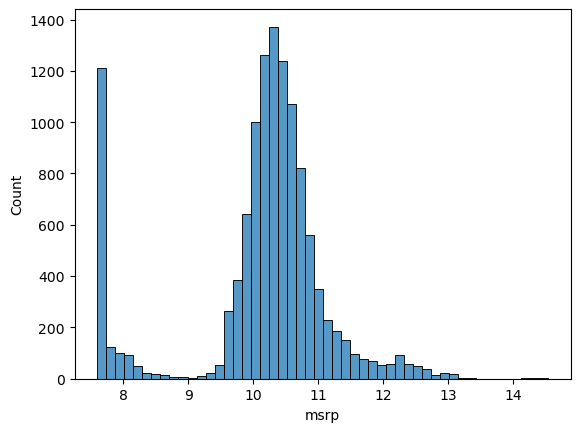

In [103]:
sns.histplot(price_logs,bins=50 ) 
plt.show

### 钟形曲线就是***正态分布***   ***normal pistribution***

### 2.3.2   处理空值  Missing  value

In [104]:
# 查找df中的空值
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

####  可以看到，所有列中的的空值统计情况
这里的空值，现在不处理，后面会有处理的步骤

## 2.4  配置验证框架  Setting up the validation framework
***注意***：这部分是MLOPS的核心工作之一：数据切分工作，通过自动化的pipeline来实现，不能手动来做，目前先学习手动逻辑
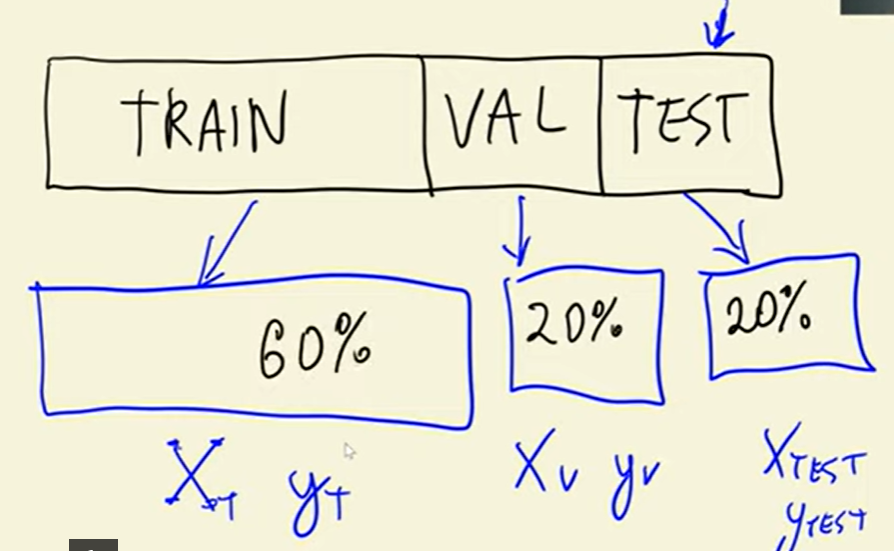

In [105]:
df.describe()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,msrp
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [106]:
df.shape[0]

11914

In [107]:
n = len(df)
n_val = int(n * 0.2)  # 算出训练数据、验证数据和测试数据所需要的行数
n_test = int(n * 0.2) 
n_train = int(n * 0.6) 

In [108]:
n,n_val + n_test + n_train  # 这样会出现数据总量的误差，所以上面的分配方式不合理，需要调整
# 这是整数除法带来的“取整误差”。在 MLOps 中，这种误差是致命的

(11914, 11912)

In [109]:
# 这种切分方法是正确的
n_train = n - n_val - n_test
n,n_val + n_test + n_train

(11914, 11914)

In [110]:
n_val , n_test , n_train

(2382, 2382, 7150)

In [111]:
# **打乱数据**，因为现有数据有一些集中分布的连续制造商信息
# 或者说，表格的某些区域中，有一些连续的具有相同趋近数值的数据，比如，这个数据集中，make列中，bmw的
# 制造商信息，就连续出现了很多，其他制造商的信息，也是如此，这样就会影响数据的均匀分布，**需要调整**
idx = np.arange(n)
np.random.seed(2)        # 固定随机种子
np.random.shuffle(idx)  #把数组 idx 的顺序打乱
df.iloc[idx[:10]]       # 这个输出结果，永远固定不变，因为使用的固定随机种子

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
8001,volkswagen,rabbit,2008,regular_unleaded,170.0,5.0,manual,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,29,22,873,17575
2882,bentley,continental_gtc,2013,premium_unleaded_(required),500.0,8.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,24,14,520,191400
649,bmw,6_series,2015,premium_unleaded_(required),315.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,coupe,32,21,3916,76100
616,maybach,57,2012,premium_unleaded_(required),543.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury",large,sedan,16,10,67,379050
4459,ford,f-150_heritage,2004,regular_unleaded,202.0,6.0,manual,four_wheel_drive,2.0,NaN,large,regular_cab_pickup,18,13,5657,26030


In [112]:
#df_val = df.iloc[:n_val]
#df_test = df.iloc[n_val:n_val+n_test]
#df_train = df.iloc[n_val+n_test:]
df_test = df.iloc[idx[n_val+n_train:]]  #取索引数组的最后 2382 行作为测试集
df_val = df.iloc[idx[n_train:n_train + n_val]] #取索引数组的中间 2382 行作为验证集
df_train = df.iloc[idx[:n_train]]# 取索引数组的前 7150 行作为训练集
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
1902,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
9334,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
5284,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [113]:
# 进行索引重置，因为上面的df_train的结果中的索引，比较无序混乱
df_train = df_train.reset_index(drop=True)  #drop=True	不保留旧索引，直接丢弃，如果不丢弃，就得索引会成为1列数据
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [114]:
# 对三个数据集的y值，进行对数转换，将长尾效应数据，变换成正态分布数据
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [115]:
y_val

array([10.19936098, 10.90872279,  9.72770457, ..., 11.21756062,
        9.77542688, 10.1924563 ], shape=(2382,))

In [116]:
# 有了y值的数据集，原来的msrp列的值，就要删除掉了，没用了
del df_train['msrp']

In [117]:
del df_val['msrp']

In [118]:
del df_test['msrp']

In [119]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657


In [120]:
df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385
1,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617
2,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657
3,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204
4,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873


In [38]:
df_test.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549
1,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617
2,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031
3,volvo,740,1992,regular_unleaded,114.0,4.0,automatic,rear_wheel_drive,4.0,luxury,midsize,sedan,26,18,870
4,ford,crown_victoria,2010,flex-fuel_(unleaded/e85),224.0,8.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,sedan,24,16,5657


## 2.5 线性回归 Linear regression 

### 线性回归 
是一种用于解决回归问题的模型。用于预测数值，模型的输出是1个数值。
下图中的X是训练特征数据
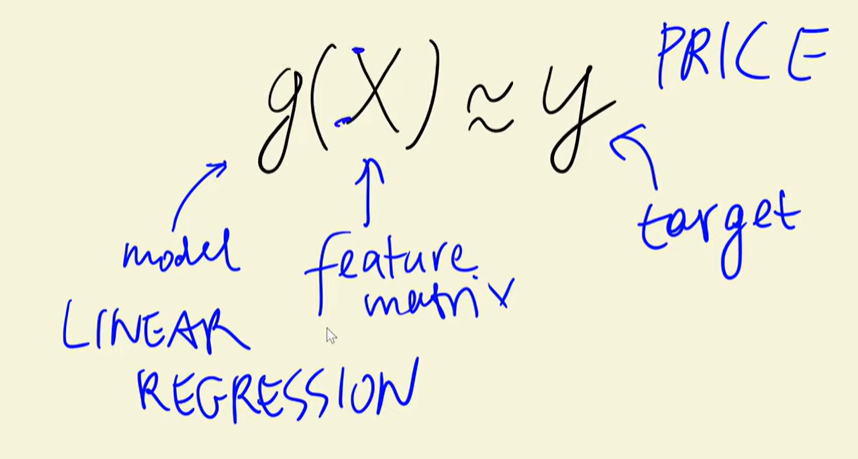

In [121]:
df_train.loc[11]

make                           chevrolet
model                            equinox
year                                2015
engine_fuel_type        regular_unleaded
engine_hp                          182.0
engine_cylinders                     4.0
transmission_type              automatic
driven_wheels            all_wheel_drive
number_of_doors                      4.0
market_category      crossover,flex_fuel
vehicle_size                     compact
vehicle_style                    4dr_suv
highway_mpg                           29
city_mpg                              20
popularity                          1385
Name: 11, dtype: object

In [122]:
xi = [182,20,1385]  # 使用其中的三个指标：发动机马力，城市油耗，受欢迎度，作为核心特征数据

### 线性回归函数的写法和理解，如图：
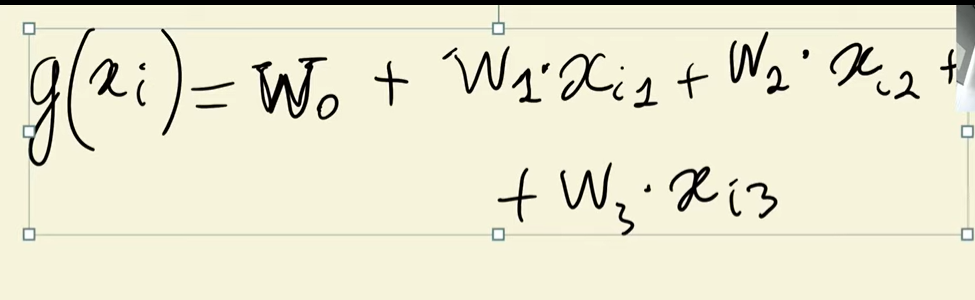
W0  表示‘截距’ intercept，代表：即使x1，x2，x3都为0，这辆车也值这个底价。作用是弥补模型的系统偏差：权重决定“坡度”，截距决定“起点高度”。
W1  表示 发动机马力的1个权重值
W2  表示 城市油耗（每加仑汽油能行驶的英里数） 的1个权重值   
W3  表示  受欢迎度的1个权重值   
替换掉：W1Xi1 + W2Xi2 +W3Xi3  这一部分,如下图
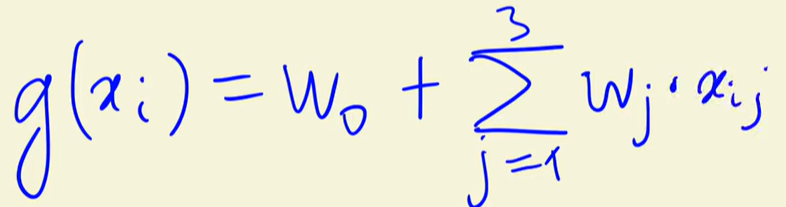
    
    下面用代码实现图中的内容

In [123]:
w0 = 7.17   # 这个假设得截距值，是对数值,确保了车辆价格不会低于1300美元左右
# 因为：np.exp(7.17)=1299.8446  7.17这个对数值还原后的原始值是这样的
w = [0.01,0.04,0.0002]  # 这是三个权重值

In [124]:
def linear_regression(xi):  #该函数返回的是对数值
    # do something
    n = len(xi)
    pred = w0
    for j in range(n):
        pred = pred + w[j] * xi[j]
    return pred

In [125]:
linear_regression(xi)  # 执行线性回归函数

10.067

In [126]:
np.expm1(10.067)  # 此处需要将对数值进行还原，还原后的数值就是实际的车辆价格

np.float64(23551.800274554327)

In [127]:
np.log1p(23551.800274554327)

np.float64(10.067)

## 2.6 线性回归向量表 Linear regression vector form

### 第2种，计算方式

In [46]:
def dot(xi,w):
    n = len(xi)
    res = 0.0
    for j in range(n):
        res = res + xi[j]*w[j]
    return res

In [47]:
def linear_regression1(xi):
    return w0 + dot(xi, w)

In [48]:
linear_regression1(xi)

10.067

### 第3种，计算方式

In [49]:

w_new = [w0] + w
w_new

[7.17, 0.01, 0.04, 0.0002]

In [50]:
def linear_regression2(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [51]:
linear_regression2(xi)

10.067

### 总结一下下
看图，上面3个线性回归的算法，其实都是1个底层逻辑：

特征值X的矩阵，去乘以，特征值的权重向量W,然后得到y值，就是预测值。
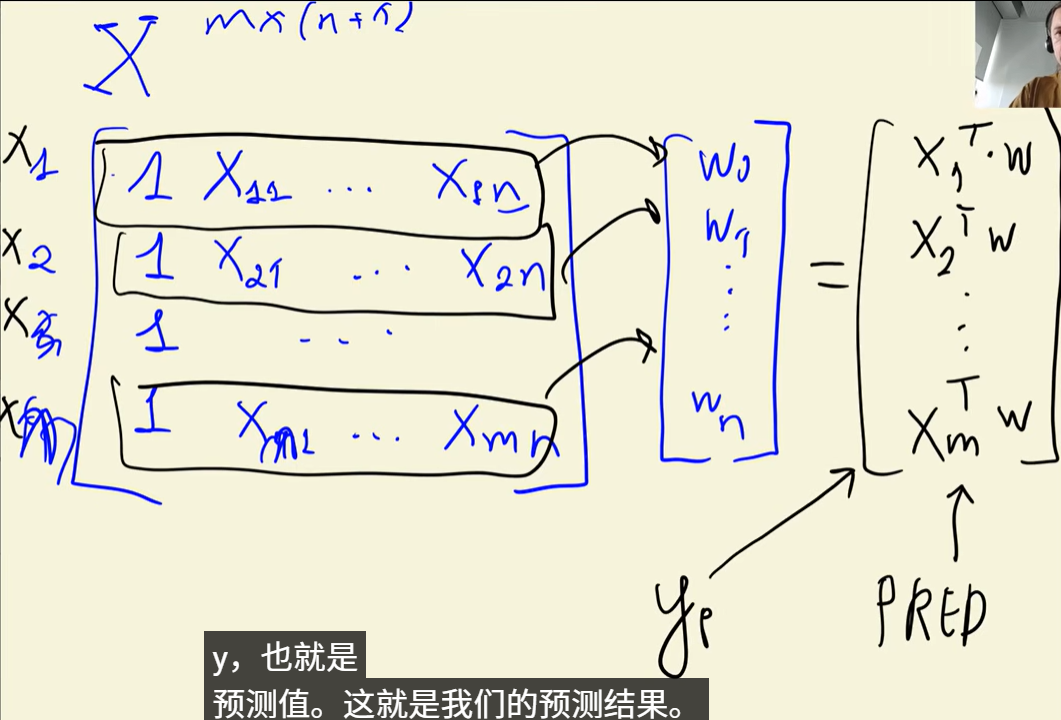

In [52]:
# 我认为以下的代码，其实就是让特征值矩阵 乘以  权重向量。
# 权重向量包含了 截距值
xi = [453, 11, 86]
w0 = 7.17
w = [0.01,0.04,0.0002]
w_new = [w0] + w

In [53]:
x1 = [1,148,24,1385]
x2 = [1,132,25,2031]
x10 = [1, 453, 11, 86]
X = [x1,x2,x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [54]:
X.dot(w_new)

array([ 9.887 ,  9.8962, 12.1572])

# 2.7 训练1个线性回归模型  Training a linear regression model

## 我们究竟如何得到权重的数值
通过前一部分的内容，我们明确知道，线性回归算法，其实就是特征矩阵 乘以 特征对应的权重向量，使得到的结果（预测值）趋近于y（就是真实值，就是上面例子中的msrp值）。这就是机器学习的“灵魂”。用更专业的术语来说，就是“最小化损失函数”。
这个公式：特征值X 乘以权重值w ，其中w就是我们要求解的关键数值
X*w ≈ y

格拉姆矩阵，就是转置矩阵 :就是把原矩阵的行变成列，列变成行

算法不深究，理解相关逻辑就行了，直接上结果：实话说，我看不懂，我觉得，也不需要懂，只要知道权重是由求解方式的，就可以了，不深究。
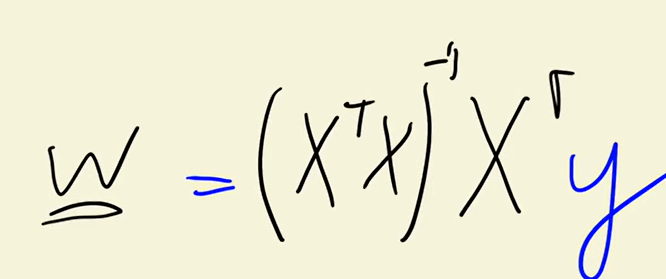
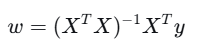
这个公式叫做线性回归的正规方程（Normal Equation）。它的作用就是：一步算出最优的权重 w。

XT  乘以 X：这个结果一定是个方阵，矩阵的转置矩阵乘以矩阵自己，结果一定是方阵。 然后对方阵求其逆矩阵，然后再乘以转置矩阵，再乘以目标向量y  

下面是权重求解的代码实现

In [128]:
X = [[148,   24, 1385],
     [132,25,2031],
    [453,11,86],
    [158,24,185],
    [172,25,201],
    [413,11,86],
    [38,54,185],
    [142,25,431],
    [453,31,86]]
X = np.array(X)  #把 Python 的普通列表（List）转换成 NumPy 的数组（Array）
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [129]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [68]:
X = np.column_stack([ones,X]) #加上这列 1 后，矩阵运算变成：y = w0​1 + w1​x1 + w2​x2 + w3​x3
# 这样模型就能自由学习出一个截距项 w0，让回归线上下浮动去贴合数据的平均水平。

In [69]:
y = [10000,20000,15000,20050,10000,20000,15000,25000,12000]  #自己定义一些目标变量
y = np.array(y)

In [59]:
XTX = X.T.dot(X)    # 转置矩阵，乘以，矩阵自己

In [60]:
XTX_inv = np.linalg.inv(XTX)  #求逆矩阵

In [61]:
XTX.dot(XTX_inv ).round(1)  #得到单位矩阵,这个不是计算步骤，用来演示理解的

array([[ 1., -0.,  0.,  0.],
       [-0.,  1.,  0.,  0.],
       [-0.,  0.,  1.,  0.],
       [-0., -0.,  0.,  1.]])

In [62]:
w_full = XTX_inv.dot(X.T).dot(y)  # 最终求解权重值
w_full

array([ 2.58447541e+04, -1.60890647e+01, -1.99472549e+02, -1.22802883e+00])

In [63]:
w0 = w_full[0]   # 找出权重向量中的截距值
w = w_full[1:]   # 剩余的是权重向量

In [64]:
w0,w

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [130]:
def train_linear_regression(X,y):  # 将上面的步骤写成1个完整的函数
    ones = np.ones(X.shape[0])  
    X = np.column_stack([ones,X]) # 在特征矩阵左侧添加一列全1，用于拟合线性回归的截距项
    XTX = X.T.dot(X) 
    XTX_inv = np.linalg.inv(XTX) 
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [131]:
train_linear_regression(X,y)

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

#### 负权重表明：该特征与目标值（价格）呈“负相关”——特征值越大，模型预测的价格越低。

# 2.8 汽车价格基准预测模型  Car price baseline model

In [132]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86


In [315]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

##### 决定使用  engine_hp，engine_cylinders，highway_mpg，city_mpg ，popularity
以上5个特征值，来构建模型。
步骤如下：
1、将训练数据，提取出5个特征值的所有数据
2、***处理***特征值中的***缺失值***
3、计算：截距值  和  权重值
4、计算：预期价格

In [316]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [133]:
base = ['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']
X_train = df_train[base].values   # 获取训练数据中指定列的数据,类型是numpy
print(type(X_train))
print(type(df_train))
df_train[base].isnull().sum()

<class 'numpy.ndarray'>
<class 'pandas.DataFrame'>


engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [134]:
X_train = df_train[base].fillna(0).values  # 处理空值，用零填充

In [135]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [136]:
w0,w = train_linear_regression(X_train,y_train)

In [137]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

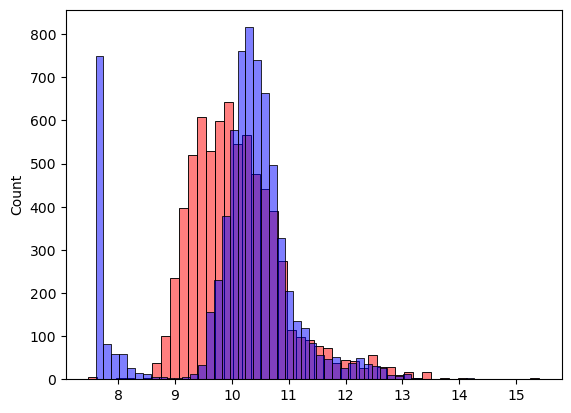

In [138]:
sns.histplot(y_pred,color = 'red',bins = 50,alpha = 0.5)    # 红色是算法生成的预测值
sns.histplot(y_train,color = 'blue',bins = 50,alpha = 0.5)  #蓝色是目标变量

# 2.9 RMSE  均方根误差

这一节，讨论如何评估回归模型，用到的方法是：RMSE 均方根误差
上一节，我通过算法，计算得出了y_pred的预测结果，并且绘制了预测值与目标变量的对比直方图
发现预测值与实际值之间存在一些偏差。但是，我们无法量化模型的误差程度。
这就是哦我们本节课要解决的问题。

In [142]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [143]:
rmse(y_train,y_pred)

np.float64(0.7554192603920132)

In [144]:
np.exp(0.7554192603920132)  # 误差率2倍多 ，0.75 对于预测车辆价格来说，误差比较大了

np.float64(2.128503733617775)

# 2.10 Validating the model  验证模型

In [145]:
# 这个函数，等同于上面的特征处理步骤，写成了函数形式
def prepare_X(df):
    df_num = df[base]  # 提取特征列数据
    df_num = df_num.fillna(0)  #对数据空值进行填充
    X= df_num.values  # 转换成numpy类型，
    return X

In [146]:
# 先处理训练数据，用符合要求的训练数据，求得 截距值和权重值
# 先处理然验证数据，用符合要求的验证数据， 做出预测价格结果，
# 然后求得均方根误差
X_train = prepare_X(df_train)
w0,w = train_linear_regression(X_train,y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val,y_pred)   # 输出均方根误差，

np.float64(0.761653099130156)

### 此处我们看到，训练集和验证集 所得到的rmse结果，是非常接近的
模型做“新题”（验证集）的水平和做“旧题”（训练集）的水平几乎一样，证明它真的学到了规律，而不是把训练数据的答案背下来了。
说明模型没有过拟合（没有死记硬背），泛化能力良好。

### 但是，均方根误差率接近2倍 ，0.75 对于预测车辆价格来说，模型误差比较大了
### 接下来，需要着手，改进模型。

# 2.11 简单得特征工程   Simple feature engineering

In [362]:
2017 - df_train.year

0        9
1        5
2        1
3       26
4        0
        ..
7145     2
7146     2
7147     2
7148     3
7149     0
Name: year, Length: 7150, dtype: int64

In [370]:
# 写1个新得数据准备函数，主体复制上面得数据准备函数
def prepare_X1(df):
    df_copy = df.copy()  # 先复制一份数据，为了安全起见，copy()是深拷贝,df 的值不会改变
    df_copy['age'] = 2017 - df_copy.year   # 添加特征列，值是汽车得车龄
    features = base + ['age']   # 将车龄特征，与base组合成新得特征
    df_num = df_copy[features]  # 提取特征列数据
    df_num = df_num.fillna(0)  #对数据空值进行填充
    X= df_num.values  # 转换成numpy类型，
    return X,df_copy


In [376]:
X_train,df_train_copy = prepare_X1(df_train)

In [372]:
df_train.dtypes    # 原始数据中，没有age字段信息

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [378]:
df_train_copy.dtypes  # 这里有了age字段

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
age                    int64
dtype: object

In [366]:
#  del df_train['age']     

In [379]:
X_train   # 此时可以看到6个特征值了

array([[1.480e+02, 4.000e+00, 3.300e+01, 2.400e+01, 1.385e+03, 9.000e+00],
       [1.320e+02, 4.000e+00, 3.200e+01, 2.500e+01, 2.031e+03, 5.000e+00],
       [1.480e+02, 4.000e+00, 3.700e+01, 2.800e+01, 6.400e+02, 1.000e+00],
       ...,
       [2.850e+02, 6.000e+00, 2.200e+01, 1.700e+01, 5.490e+02, 2.000e+00],
       [5.630e+02, 1.200e+01, 2.100e+01, 1.300e+01, 8.600e+01, 3.000e+00],
       [2.000e+02, 4.000e+00, 3.100e+01, 2.200e+01, 8.730e+02, 0.000e+00]],
      shape=(7150, 6))

In [380]:
# 按照新的6个特征值，看一下rmse的结果，发现***有大幅度***改进
w0,w = train_linear_regression(X_train,y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val,y_pred)

np.float64(0.5172055461058299)

<Axes: ylabel='Count'>

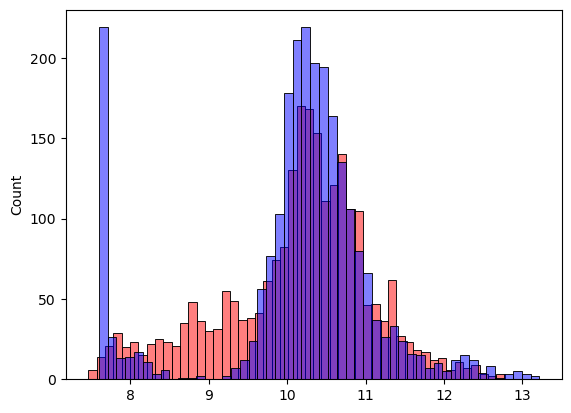

In [382]:
sns.histplot(y_pred,color = 'red',bins = 50,alpha = 0.5)    # 红色是算法生成的预测值
sns.histplot(y_val,color = 'blue',bins = 50,alpha = 0.5)  #蓝色是目标变量

#### 这说明通过添加更多，影响价格的关键的特征值，可以让预测值与目标值更为接近。

# 2.12  分类变量   categorical variable

#### 分类变量：具有不同类别的变量，是字符串类型，而不是数字类型。

In [384]:
df_train.dtypes  # str类型都是分类变量，包括’number_of_doors    float64‘也是分类变量

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [388]:
(df_train['number_of_doors'] == 2).astype('int')

0       1
1       0
2       0
3       0
4       0
       ..
7145    1
7146    1
7147    0
7148    0
7149    0
Name: number_of_doors, Length: 7150, dtype: int64

In [5]:
# 这是一段非常经典的 One-Hot 编码（独热编码） 的代码，
# 它的作用是：把 number_of_doors 这一列中的“车门数量”，拆分成多个独立的 0/1 二值列。
for v in [2,3,4]:
    df_train['num_doors_%s' % v] = (df_train['number_of_doors'] == v).astype('int')

NameError: name 'df_train' is not defined

In [1]:
df_train

NameError: name 'df_train' is not defined

In [396]:
#  del df_train['num_doors_4']

In [147]:
# 修改数据准备函数
def prepare_X2(df):
    df_copy = df.copy()  # 先复制一份数据，为了安全起见，copy()是拷贝,df 的值不会因为函数内部处理数据而改变，因为df是引用类型
    df_copy['age'] = 2017 - df_copy.year   # 添加特征列，值是汽车得车龄
    features = base + ['age']   # 将车龄特征，与base组合成新得特征

    for v in [2,3,4]:
        df_copy['num_doors_%s' % v] = (df_copy['number_of_doors'] == v).astype('int') 
        features.append('num_doors_%s' % v)
        
    df_num = df_copy[features]  # 提取特征列数据
    df_num = df_num.fillna(0)  #对数据空值进行填充
    X= df_num.values  # 转换成numpy类型，
    return X

In [148]:
X_train = prepare_X2(df_train)

In [149]:
w0,w = train_linear_regression(X_train,y_train)

X_val = prepare_X2(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val,y_pred)

np.float64(0.515799564150169)

<Axes: ylabel='Count'>

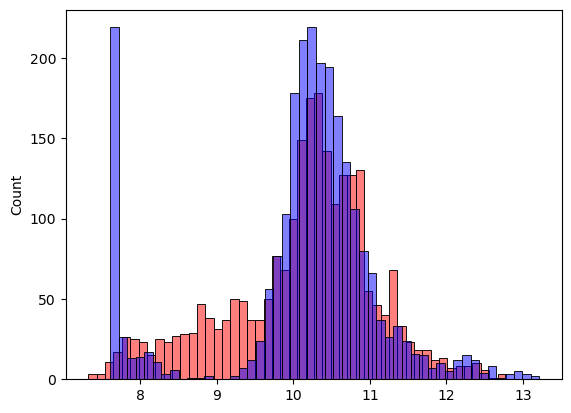

In [150]:
sns.histplot(y_pred,color = 'red',bins = 50,alpha = 0.5)    # 红色是算法生成的预测值
sns.histplot(y_val,color = 'blue',bins = 50,alpha = 0.5)  #蓝色是目标变量

#### 我们发现改进十分微小，从图表上看，几乎看不到车门数这个特征增加后，对结果的改进。
#### 我们接下来尝试增加 ’'品牌‘' 这个特征

In [151]:
# 查看最受欢迎的前5位的品牌
makes = list(df.make.value_counts().head().index)   #value_counts() 是 Pandas 的内置函数，专用于 Series（单列数据）。

In [152]:
# 修改数据准备函数
def prepare_X3(df):
    df_copy = df.copy()  # 先复制一份数据，为了安全起见，copy()是拷贝,df 的值不会因为函数内部处理数据而改变，因为df是引用类型
    df_copy['age'] = 2017 - df_copy.year   # 添加特征列，值是汽车得车龄
    features = base + ['age']   # 将车龄特征，与base组合成新得特征

    for v in [2,3,4]:
        df_copy['num_doors_%s' % v] = (df_copy['number_of_doors'] == v).astype('int') 
        features.append('num_doors_%s' % v)
    for v in makes:
        df_copy['make_%s' % v] = (df_copy['make'] == v).astype('int') 
        features.append('make_%s' % v)
    
    df_num = df_copy[features]  # 提取特征列数据
    df_num = df_num.fillna(0)  #对数据空值进行填充
    X= df_num.values  # 转换成numpy类型，
    return X 

In [153]:
X_train = prepare_X3(df_train)
w0,w = train_linear_regression(X_train,y_train)

X_val = prepare_X3(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val,y_pred)

np.float64(0.5076038849556795)

In [154]:
X_train

array([[148.,   4.,  33., ...,   0.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   1.,   0.],
       [148.,   4.,  37., ...,   0.,   0.,   0.],
       ...,
       [285.,   6.,  22., ...,   0.,   0.,   0.],
       [563.,  12.,  21., ...,   0.,   0.,   0.],
       [200.,   4.,  31., ...,   1.,   0.,   0.]], shape=(7150, 14))

In [155]:
# 上面完成了 车辆年限，车门数和制造商的3个分类，并将3个分类加入特征，除了车辆年限，和车门数，这两个特殊的特征，make特征的特点就是
# 需要把衡量字符对应转换的条件设定好，比如make是匹配前5的制造商信息，如果匹配字符后对应转换成0或1
# 接下来要做的所有分类，都是属于字符型的，处理逻辑同上
categorical_variables = ['make','engine_fuel_type','transmission_type','driven_wheels','market_category','vehicle_size','vehicle_style']

In [156]:
categories = {}
for c in categorical_variables:
    categories[c] = list(df[c].value_counts().head().index) 
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [157]:
# 修改数据准备函数
def prepare_X4(df):
    df_copy = df.copy()  # 先复制一份数据，为了安全起见，copy()是拷贝,df 的值不会因为函数内部处理数据而改变，因为df是引用类型
    df_copy['age'] = 2017 - df_copy.year   # 添加特征列，值是汽车得车龄
    features = base + ['age']   # 将车龄特征，与base组合成新得特征

    for v in [2,3,4]:
        df_copy['num_doors_%s' % v] = (df_copy['number_of_doors'] == v).astype('int') 
        features.append('num_doors_%s' % v)
    for c, values in categories.items():
        for v in values:
            df_copy['%s_%s' % (c,v)] = (df_copy[c] == v).astype('int') 
            features.append('%s_%s' % (c,v))
    
    df_num = df_copy[features]  # 提取特征列数据
    df_num = df_num.fillna(0)  #对数据空值进行填充
    X= df_num.values  # 转换成numpy类型，
    return X 

In [158]:
X_train = prepare_X4(df_train)
w0,w = train_linear_regression(X_train,y_train)

X_val = prepare_X4(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val,y_pred)

np.float64(23.019020704791835)

In [448]:
w   # 从这里，你会看到，巨夸张的权重值 -4.60060984e+15, -4.60060984e+15, -4.60060984e+15, -4.60060984e+15,
#        5.89518839e+14,  5.89518839e+14,  5.89518839e+14,  5.89518839e+14, 
# 这些值极为不合理，如何产生的呢？ 如何处理呢，看下一节吧。

array([ 5.17477261e-02,  5.87434156e+00,  2.58988500e+00, -9.14739385e-01,
        3.29434090e-03,  1.26747065e+00,  1.09365186e+03,  1.08197230e+03,
        1.08519232e+03, -2.94630727e+00, -7.48076191e+00,  1.02357603e+01,
       -8.56657044e-01, -2.27736086e+00,  1.84973907e+00, -3.51656880e+00,
       -2.20958315e+00,  6.07018281e+00, -3.32427158e+01, -4.60060984e+15,
       -4.60060984e+15, -4.60060984e+15, -4.60060984e+15, -4.60060984e+15,
        5.89518839e+14,  5.89518839e+14,  5.89518839e+14,  5.89518839e+14,
       -9.26775404e-01,  3.51631589e-01,  1.80584944e-01,  1.46169331e+00,
       -1.67201746e+00, -3.59104780e+00, -6.16304692e+00, -5.45706022e+00,
       -4.85492239e-02,  5.44797374e-02,  1.78241160e-01,  3.41906701e-01,
       -1.64412078e-01])

# 2.13  规范化    Regilarization
就是控制权重值，不要偏差太大
就是通过参数，控制方阵中数据重复列

In [461]:
xx = [[4,4,4],[3,5,5],[5,1,1],[5,4,4],[7,5,5],[4,5,5]]
xxx = np.array(xx)
xxx   # 这个numpy 数组矩阵的第2列和第3列，数值是一样的。

array([[4, 4, 4],
       [3, 5, 5],
       [5, 1, 1],
       [5, 4, 4],
       [7, 5, 5],
       [4, 5, 5]])

我们按照权重值求解的公式，把xxx的方阵计算一下

In [463]:
xtx = xxx.T.dot(xxx)  # 你会发现，这个方阵，第2列和第3列的数值是一样的
xtx

array([[140, 111, 111],
       [111, 108, 108],
       [111, 108, 108]])

In [464]:
np.linalg.inv(xtx)  # 将方阵xtx，求其逆矩阵，发现报错了

LinAlgError: Singular matrix

#### 奇异矩阵不能求逆矩阵，所以报错了！！！！！！！！！！
#### 奇异矩阵：有完全相同的两列，有1列全是0，有1列是另一列的倍数
#### 解决的办法就是：xxx矩阵中的相同列，处理一下，让其不相同了.注意要进行非常细微的调整，如下

In [484]:
xx1 = [[4,4,4],[3,5,5],[5,1,1],[5,4,4],[7,5,5],[4,5,5.0000001]]
xxx1 = np.array(xx1)
xxx1

array([[4.       , 4.       , 4.       ],
       [3.       , 5.       , 5.       ],
       [5.       , 1.       , 1.       ],
       [5.       , 4.       , 4.       ],
       [7.       , 5.       , 5.       ],
       [4.       , 5.       , 5.0000001]])

In [488]:
y = [1,2,3,1,2,3]

In [485]:
xtx1 = xxx1.T.dot(xxx1)  # 你会发现，这个方阵，第2列和第3列的数值是一样的
xtx1

array([[140.       , 111.       , 111.0000004],
       [111.       , 108.       , 108.0000005],
       [111.0000004, 108.0000005, 108.000001 ]])

In [487]:
xtx1_inv = np.linalg.inv(xtx1)
xtx1_inv

array([[ 3.92646538e-02, -1.54615164e+05,  1.54615121e+05],
       [-1.54615170e+05,  3.51843724e+13, -3.51843721e+13],
       [ 1.54615129e+05, -3.51843721e+13,  3.51843718e+13]])

In [489]:
xtx1_inv.dot(xxx1.T).dot(y)  #求解权重值

array([ 2.73776578e-01, -4.41093100e+06,  4.41093113e+06])

#### 发现问题：第一个值是 0.2737,第2个值和第3个值，已经很夸张了，正负400多万了
通过下面的办法，解决权重过大的问题。

In [517]:
xx2 =[[1,2,2],
      [2,1,1.0000001],
      [2,1.0000001,1]]
xxx2 = np.array(xx2)
xxx2

array([[1.       , 2.       , 2.       ],
       [2.       , 1.       , 1.0000001],
       [2.       , 1.0000001, 1.       ]])

In [518]:
np.linalg.inv(xxx2)  #求解逆矩阵  发现这值都大的夸张

array([[-3.33333356e-01,  3.33333339e-01,  3.33333339e-01],
       [ 3.33333339e-01, -5.00000008e+06,  4.99999991e+06],
       [ 3.33333339e-01,  4.99999991e+06, -5.00000008e+06]])

In [519]:
xxx2 + np.eye(3) # np.eye(3)  是1个3*3的单位矩阵，结果会把单位矩阵的1加到xxx2矩阵中

array([[2.       , 2.       , 2.       ],
       [2.       , 2.       , 1.0000001],
       [2.       , 1.0000001, 2.       ]])

In [514]:
0.01*np.eye(3)

array([[0.01, 0.  , 0.  ],
       [0.  , 0.01, 0.  ],
       [0.  , 0.  , 0.01]])

In [520]:
xxx3 = xxx2 + 0.01 * np.eye(3)   #
xxx3

array([[1.01     , 2.       , 2.       ],
       [2.       , 1.01     , 1.0000001],
       [2.       , 1.0000001, 1.01     ]])

In [522]:
np.linalg.inv(xxx3)   # 这次逆矩阵的结果就没有上面那么夸张了，就因为，在矩阵的斜对角上，增加了0.01

array([[ -0.33668908,   0.33501399,   0.33501399],
       [  0.33501399,  49.91590897, -50.08509104],
       [  0.33501399, -50.08509104,  49.91590897]])

#### 以上就是 ‘规范化’ 解决权重值偏差过大的逻辑过程
#### 下面根据上面的逻辑，我们修改权重值函数


In [159]:
def train_linear_regression_reg(X,y,r=0.001):  # 添加了规范化逻辑的权重计算函数,r就是这个规范化的参数
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])
    
    XTX = X.T.dot(X) 
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX) 
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [160]:
X_train = prepare_X4(df_train)
w0,w = train_linear_regression_reg(X_train,y_train,r=0.01)

X_val = prepare_X4(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val,y_pred)

np.float64(0.45652199012897743)

#### 通过结果可以看出来，这是目前偏差最小的结果，完全是通过在求取权重值的方阵的对角线上，乘以1个r值，就可以提高模型的精度，改变偏差大的局面。
#### 通过调整r值，我们能看到偏差的变化，所以接下来，找到最优的r值，就是我们要做的工作

# 2.14   微调模型  tuning the model

#### 本节讨论，如何找到线性回归模型的最佳规范化参数
参数r，会影响模型的质量。我们需要找到模型的最佳r值

In [161]:
for r in [0.0,0.00001,0.0001,0.001,0.01,0.1,1,10]:
    X_train = prepare_X4(df_train)
    w0,w = train_linear_regression_reg(X_train,y_train,r=r)
    
    X_val = prepare_X4(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val,y_pred)

    print(r,w0,score)

0.0 4011091003551887.0 23.019020704791835
1e-05 6.178192055025445 0.45651702823445617
0.0001 6.317246071243372 0.45651706543230514
0.001 6.285636717989048 0.4565175086778138
0.01 6.2766071476973995 0.45652199012897743
0.1 6.1912087238544915 0.4565692763007501
1 5.634896668066369 0.45722043179930605
10 4.283980108968471 0.4701456932099909


In [4]:
np.expm1( 6.285636717989048 )

np.float64(535.8059758688526)

# 2.15 应用模型  Using the model 

### 使用最佳参数r，来训练最终模型

#### 到目前为止，所作得工作总结为：
训练数据集上训练模型，得到截距值和权重值，然后求出训练数据集得预测值和rmse值 
用这两个值，再用验证数据，起初验证数据集得预测值和rmse值。
训练 + 验证 = FULL TRAIN  这个概念已经完成

#### 接下来我们要做得事情
在测试集上，进行最终验证，确保模型运行良好，并检查其rmse与验证集差别可接受


In [171]:
df_full_train  = pd.concat([df_train,df_val])

In [175]:
df_full_train  = df_full_train.reset_index(drop=True) # 重置索引，删除旧索引

In [176]:
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870
9528,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238
9529,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624
9530,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436


In [178]:
X_full_train = prepare_X4(df_full_train)  # 构建 特征值
X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

In [179]:
y_full_train = np.concatenate([y_train,y_val])   #求训练集y值和验证集y值，的和
y_full_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 11.21756062,
        9.77542688, 10.1924563 ], shape=(9532,))

In [180]:
w0,w = train_linear_regression_reg(X_full_train ,y_full_train,r=0.001)

In [181]:
w0

np.float64(6.322830302349775)

In [182]:
w

array([ 1.52506332e-03,  1.18188703e-01, -6.66105494e-03, -5.33413785e-03,
       -4.87603208e-05, -9.69091838e-02, -7.92620449e-01, -8.90861655e-01,
       -6.35100382e-01, -4.14339224e-02,  1.75560743e-01, -5.78063598e-04,
       -1.00563877e-01, -9.27549641e-02, -4.66859195e-01,  7.98658894e-02,
       -3.16047745e-01, -5.51981714e-01, -7.89526802e-02,  1.09397462e+00,
        9.18667079e-01,  1.14824449e+00,  2.65138017e+00,  5.08603719e-01,
        1.62979575e+00,  1.53049981e+00,  1.61767854e+00,  1.54567793e+00,
       -9.70559706e-02,  3.73062128e-02, -5.81767490e-02, -2.35940871e-02,
       -1.19357192e-02,  2.18895260e+00,  2.07458270e+00,  2.05916686e+00,
       -5.00802769e-02,  5.62184639e-02,  1.84794024e-01,  3.32646151e-01,
       -1.58817038e-01])

In [183]:
X_test = prepare_X4(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test,y_pred)
score

np.float64(0.4517749310621406)

### 最终模型已经成型
### 结果表明模型泛化能力比较强，rmse的值，都比较接近
### 我们可以用模型来预测车辆的价格
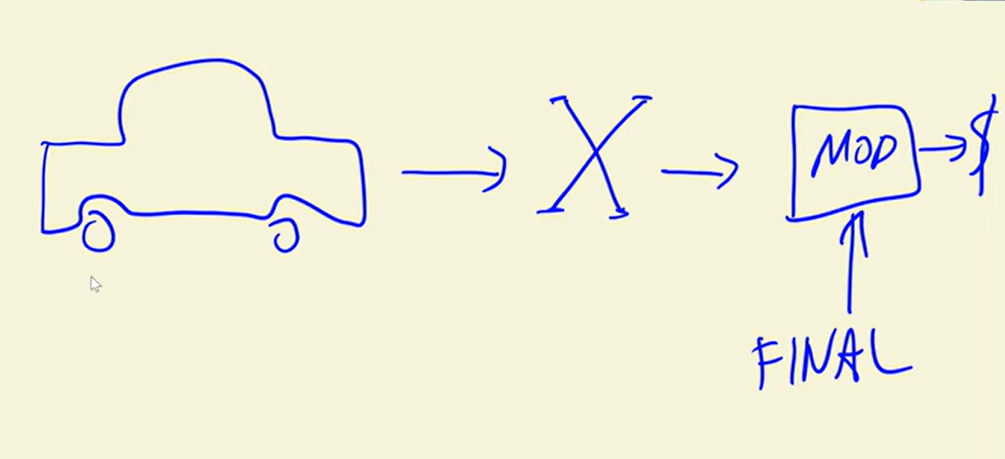

In [188]:
car = df_test.iloc[20].to_dict()    
# 测试数据集中选取一辆车，假设它是一辆新车，转换成字典类型，模仿前端输入的的车辆信息
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [189]:
# 要给prepare_X4 这个模型传入数据，需要处理car的数据 
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [190]:
X_small = prepare_X4(df_small)
X_small

array([[2.660e+02, 6.000e+00, 2.500e+01, 1.800e+01, 2.031e+03, 2.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]])

In [192]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(10.462651700289744)

In [193]:
np.expm1(y_pred)   # 预测的最终结果

np.float64(34983.19616272936)

In [194]:
y_test[20]  # 看看这辆车的真实价格  ，预测结果，和真实结果几乎一样了

np.float64(10.463131911491967)

In [195]:
np.expm1(y_test[20])  # 预测结果只比实际值，少了17美元

np.float64(35000.00000000001)